02 - Exploratory Data Analysis

This notebook explores the COVID-19 Romania dataset.

The analysis focuses on:
1. Top counties by confirmed cases
2. Confirmed cases over time
3. Monthly confirmed cases
4. Risk level distribution on the latest date
5. Country-level indicators

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

processed_folder = "../data/processed"
screenshots_folder = "../screenshots"

os.makedirs(screenshots_folder, exist_ok=True)

county_file = os.path.join(processed_folder, "covid_county_clean.csv")
country_file = os.path.join(processed_folder, "covid_country_clean.csv")

print("Setup completed.")

Setup completed.


STEP 1 - Load the Processed Data

The cleaned county-level and country-level datasets are loaded from the processed folder.

In [2]:
county_df = pd.read_csv(county_file)
country_df = pd.read_csv(country_file)

county_df["Date"] = pd.to_datetime(county_df["Date"])
country_df["date"] = pd.to_datetime(country_df["date"])

print("County dataset shape:", county_df.shape)
print("Country dataset shape:", country_df.shape)

county_df.head()

County dataset shape: (4624, 8)
Country dataset shape: (113, 11)


,County,Confirmed,Date,Year,Month,Month_Name,Day,Risk_Level
0,Alba,9,2020-04-02,2020,4,April,2,Low
1,Alba,13,2020-04-03,2020,4,April,3,Low
2,Alba,15,2020-04-04,2020,4,April,4,Low
3,Alba,33,2020-04-05,2020,4,April,5,Low
4,Alba,34,2020-04-06,2020,4,April,6,Low


STEP 2 - Dataset Overview

This step checks the columns, missing values, and date range.

In [3]:
print("County columns:")
print(county_df.columns.tolist())

print("\nMissing values:")
print(county_df.isna().sum())

print("\nDate range:")
print(county_df["Date"].min(), "to", county_df["Date"].max())

print("\nNumber of counties:")
print(county_df["County"].nunique())

County columns:
['County', 'Confirmed', 'Date', 'Year', 'Month', 'Month_Name', 'Day', 'Risk_Level']

Missing values:
County        0
Confirmed     0
Date          0
Year          0
Month         0
Month_Name    0
Day           0
Risk_Level    0
dtype: int64

Date range:
2020-04-02 00:00:00 to 2020-07-21 00:00:00

Number of counties:
43


STEP 3 - Top 10 Counties by Total Confirmed Cases

This chart shows the counties with the highest number of confirmed COVID-19 cases.

The latest available date is used.

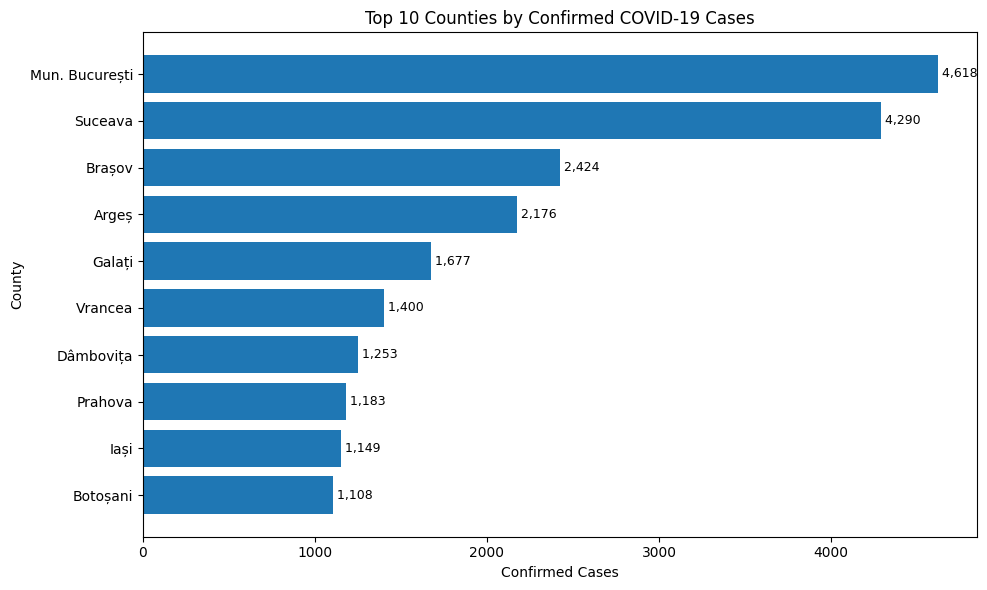

In [4]:
latest_date = county_df["Date"].max()
latest_county_data = county_df[county_df["Date"] == latest_date]

top_counties = (
    latest_county_data
    .sort_values("Confirmed", ascending=False)
    .head(10)
    .sort_values("Confirmed")
)

plt.figure(figsize=(10, 6))

bars = plt.barh(top_counties["County"], top_counties["Confirmed"])

plt.title("Top 10 Counties by Confirmed COVID-19 Cases")
plt.xlabel("Confirmed Cases")
plt.ylabel("County")

for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {int(bar.get_width()):,}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(os.path.join(screenshots_folder, "01_top_counties_confirmed.png"))
plt.show()

STEP 4 - Confirmed Cases Over Time in Romania

This chart shows the evolution of total confirmed cases at country level.

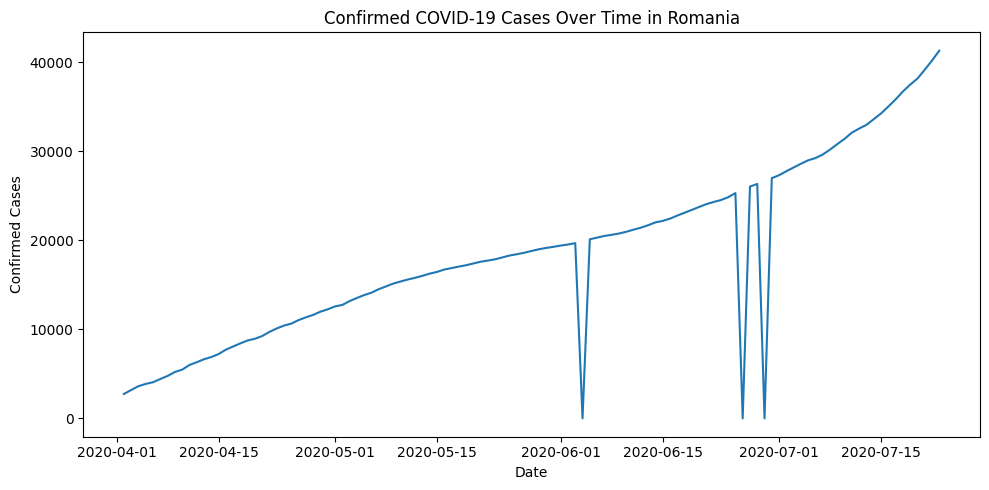

In [5]:
plt.figure(figsize=(10, 5))

plt.plot(country_df["date"], country_df["confirmed"])

plt.title("Confirmed COVID-19 Cases Over Time in Romania")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")

plt.tight_layout()
plt.savefig(os.path.join(screenshots_folder, "02_confirmed_cases_over_time.png"))
plt.show()

STEP 5 - Confirmed Cases by Date

This chart shows the total confirmed cases across all counties for each date.

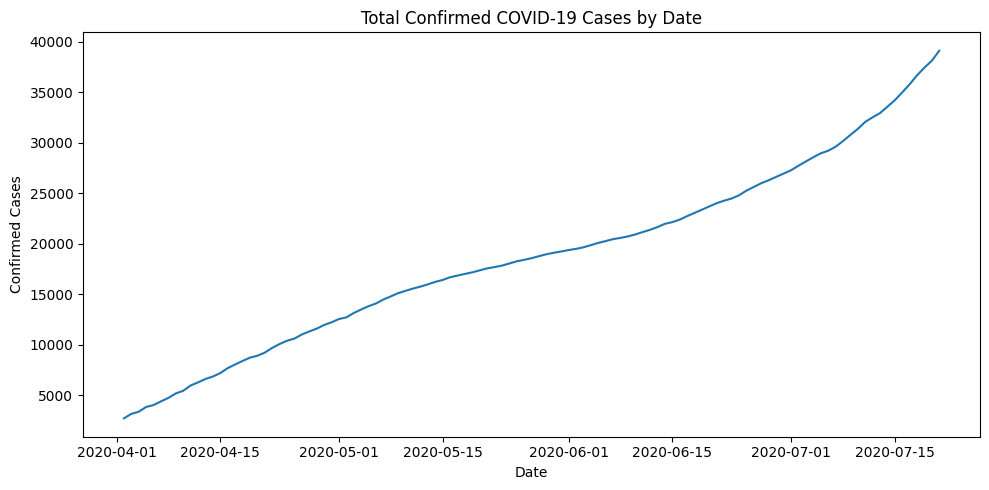

In [6]:
cases_by_date = (
    county_df
    .groupby("Date")["Confirmed"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.plot(cases_by_date["Date"], cases_by_date["Confirmed"])

plt.title("Total Confirmed COVID-19 Cases by Date")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")

plt.tight_layout()
plt.savefig(os.path.join(screenshots_folder, "03_confirmed_cases_by_date.png"))
plt.show()

STEP 6 - Monthly Confirmed Cases

This chart shows confirmed cases grouped by year and month.

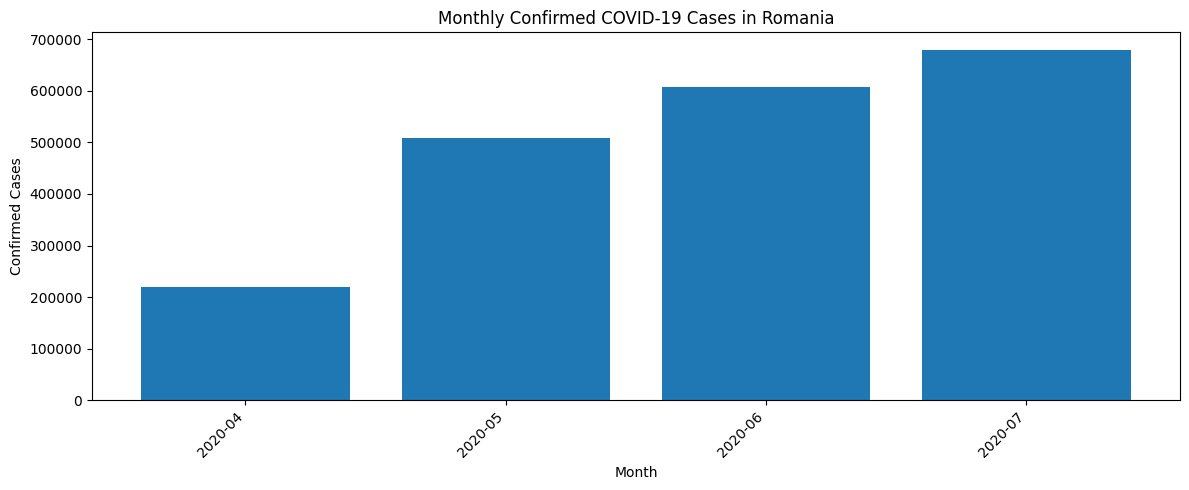

In [7]:
monthly_cases = (
    county_df
    .groupby(["Year", "Month"])["Confirmed"]
    .sum()
    .reset_index()
)

monthly_cases["Year_Month"] = (
    monthly_cases["Year"].astype(str) + "-" +
    monthly_cases["Month"].astype(str).str.zfill(2)
)

plt.figure(figsize=(12, 5))

plt.bar(monthly_cases["Year_Month"], monthly_cases["Confirmed"])

plt.title("Monthly Confirmed COVID-19 Cases in Romania")
plt.xlabel("Month")
plt.ylabel("Confirmed Cases")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig(os.path.join(screenshots_folder, "04_monthly_confirmed_cases.png"))
plt.show()

STEP 7 - Risk Level Distribution on Latest Date

This chart shows how many counties are classified as Low, Medium, or High risk on the latest available date.

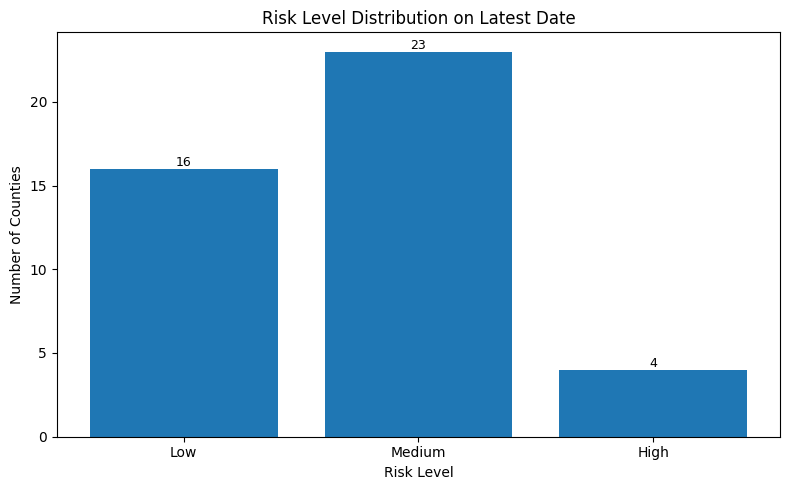

In [8]:
latest_date = county_df["Date"].max()
latest_risk_data = county_df[county_df["Date"] == latest_date]

risk_counts = latest_risk_data["Risk_Level"].value_counts()

risk_order = ["Low", "Medium", "High"]
risk_counts = risk_counts.reindex(risk_order).fillna(0)

plt.figure(figsize=(8, 5))

bars = plt.bar(risk_counts.index, risk_counts.values)

plt.title("Risk Level Distribution on Latest Date")
plt.xlabel("Risk Level")
plt.ylabel("Number of Counties")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(os.path.join(screenshots_folder, "05_risk_level_distribution.png"))
plt.show()

STEP 8 - Latest Country-Level Indicators

This chart compares important national COVID-19 indicators from the latest available date.

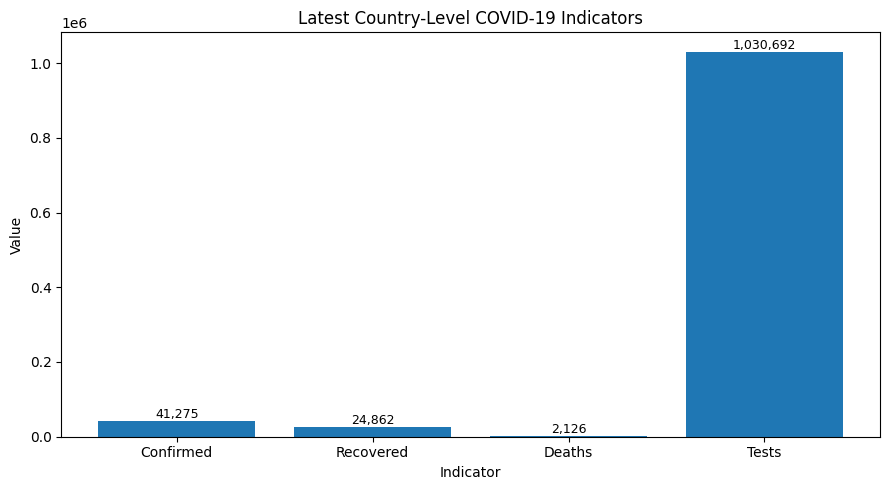

In [9]:
latest_country = country_df[country_df["date"] == country_df["date"].max()].iloc[0]

indicators = {
    "Confirmed": latest_country["confirmed"],
    "Recovered": latest_country["recovered"],
    "Deaths": latest_country["deaths"],
    "Tests": latest_country["tests"]
}

plt.figure(figsize=(9, 5))

bars = plt.bar(indicators.keys(), indicators.values())

plt.title("Latest Country-Level COVID-19 Indicators")
plt.xlabel("Indicator")
plt.ylabel("Value")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(os.path.join(screenshots_folder, "06_country_indicators.png"))
plt.show()
plt.show()

STEP 9 - Main EDA Findings

The exploratory analysis shows the main COVID-19 patterns in Romania.

Main findings:
1. Some counties recorded higher confirmed case numbers.
2. Confirmed cases increased over time at country level.
3. Monthly trends show changes across the observed period.
4. Risk level is clearer when analyzed on the latest available date.

In [10]:
print("EDA completed successfully.")
print("Charts saved in:", screenshots_folder)

for file in os.listdir(screenshots_folder):
    if file.endswith(".png"):
        print(file)

EDA completed successfully.
Charts saved in: ../screenshots
01_top_counties_confirmed.png
02_confirmed_cases_over_time.png
03_confirmed_cases_by_date.png
04_monthly_confirmed_cases.png
05_risk_level_distribution.png
06_country_indicators.png
07_ml_risk_distribution.png
08_confusion_matrix.png
09_avg_confirmed_by_risk.png
